# EY Water Quality — LightGBM Parallel Model
**Purpose:** Run alongside CatBoost model for ensembling.  
Same pipeline: spatial GroupKFold, Optuna tuning, log1p(DRP), feature pruning.  
Different model: LightGBM (leaf-wise growth) complements CatBoost (symmetric trees).

In [2]:
# Install if needed (uncomment)
!pip install optuna lightgbm shap --quiet

In [3]:
import pandas as pd
import numpy as np
import os
import optuna
import shap
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
import warnings
import matplotlib.pyplot as plt
import json

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\knich\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\knich\miniconda3\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\knich\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\knich\miniconda3\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [4]:
# ==========================================
# 1. CONFIGURATION — CHANGE PATHS HERE
# ==========================================
class Config:
    # >>> CHANGE THIS to your local data folder <<<
    BASE_DIR = './data'  # or r'C:\Users\you\EY_Datathon' on Windows
    
    SEED = 85
    N_FOLDS = 5
    N_OPTUNA_TRIALS = 30  # Bump up from 20 — LightGBM is faster
    TARGETS = [
        'Total Alkalinity',
        'Electrical Conductance',
        'Dissolved Reactive Phosphorus'
    ]
    DWS_FEATS = ['dws_TAL', 'dws_EC', 'dws_PO4_P', 'dws_pH',
                 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl', 'dws_SO4']

In [5]:
# ==========================================
# 2. SAME ENGINEERING UTILITIES
# ==========================================
def engineer_features(df):
    temp_df = df.copy()
    
    # Remote Sensing Ratios
    if 'nir' in temp_df.columns and 'green' in temp_df.columns:
        temp_df['nir_green_ratio'] = temp_df['nir'] / (temp_df['green'] + 1e-6)
    
    # Log-transform skewed features
    skewed_feats = ['Popdens_00', 'SOC', 'dist_km']
    for feat in skewed_feats:
        if feat in temp_df.columns:
            temp_df[f'log_{feat}'] = np.log1p(temp_df[feat])
    
    return temp_df


def prune_features(X, correlation_threshold=0.95):
    # Remove constant columns
    X = X.loc[:, X.nunique() > 1]
    
    # Remove highly correlated features
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > correlation_threshold)]
    print(f"Dropped {len(to_drop)} features due to high correlation (> {correlation_threshold})")
    return X.drop(columns=to_drop)

In [6]:
# ==========================================
# 3. DATA LOADING & SPATIAL CV SETUP
# ==========================================
print("Loading datasets...")
train_full = pd.read_csv(f'{Config.BASE_DIR}/train_ALL+reliability.csv')
test_full = pd.read_csv(f'{Config.BASE_DIR}/test_ALL+reliability.csv')

# Cluster stations for Spatial CV (identical to CatBoost pipeline)
stations = train_full.groupby(['Latitude', 'Longitude']).size().reset_index()
kmeans = KMeans(n_clusters=Config.N_FOLDS, random_state=Config.SEED, n_init=10)
stations['spatial_cluster'] = kmeans.fit_predict(stations[['Latitude', 'Longitude']])

train_full = train_full.merge(
    stations[['Latitude', 'Longitude', 'spatial_cluster']],
    on=['Latitude', 'Longitude'], how='left'
)

# Engineer
train_eng = engineer_features(train_full)
test_eng = engineer_features(test_full)

print(f"Train shape: {train_eng.shape}, Test shape: {test_eng.shape}")

Loading datasets...
Train shape: (9319, 83), Test shape: (200, 81)


In [7]:
# ==========================================
# 4. FEATURE SET (same exclusions as CatBoost)
# ==========================================
ignore_cols = Config.TARGETS + [
    'Latitude', 'Longitude', 'STAT_ID', 'Sample Date',
    'spatial_cluster', 'geometry', '_merge_terra',
    '_merge_landsat', 'Latitude_glorich',
    'Longitude_glorich', 'date', 'dws_1st', 'Impute_Method'
]
features = [c for c in train_eng.columns if c not in ignore_cols]

X_train_clean = prune_features(train_eng[features])

# Drop same cols as CatBoost version
drop_extra = ['P_modified_same', 'dws_P_reliability']
drop_extra = [c for c in drop_extra if c in X_train_clean.columns]
X_train_clean.drop(columns=drop_extra, inplace=True)

X_test_clean = test_eng[X_train_clean.columns]

print(f"Final feature count: {X_train_clean.shape[1]}")
print(f"Features: {list(X_train_clean.columns)}")

Dropped 7 features due to high correlation (> 0.95)
Final feature count: 56
Features: ['pet', 'nir', 'green', 'swir16', 'NDMI', 'MNDWI', 'sc', 'ss', 'su', 'mt', 'va', 'vb', 'vi', 'pa', 'pb', 'pi', 'GLC_Artificial', 'GLC_Managed', 'GLC_Water', 'Popdens_00', 'Soil_pH', 'SOC', 'Soil_wetness', 'dist_m', 'Alkalinity', 'Cl', 'DIP', 'SO4', 'SpecCond25C', 'pH', 'Alkalinity_reliability', 'Cl_reliability', 'DIP_reliability', 'SO4_reliability', 'SpecCond25C_reliability', 'pH_reliability', 'date_diff_days', 'dws_1st_dist', 'dws_TAL', 'dws_EC', 'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Cl', 'dws_SO4', 'dws_days_diff', 'dws_P_modified', 'month', 'year', 'month_sin', 'month_cos', 'doy_cos', 'wet_season', 'nir_green_ratio', 'log_Popdens_00', 'log_dist_km']


In [8]:
# ==========================================
# 5. LIGHTGBM OPTUNA OBJECTIVE
# ==========================================
def lgbm_objective(trial, X, y, groups, target_name):
    """
    LightGBM-native search space.
    Key difference from CatBoost: leaf-wise growth => num_leaves is the
    primary complexity knob, not depth.
    """
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': Config.SEED,
        'n_jobs': -1,  # Use all local cores
        
        # Core complexity
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        
        # Stochastic
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample_freq': 1,
    }
    
    gkf = GroupKFold(n_splits=Config.N_FOLDS)
    scores = []
    
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        model = lgb.LGBMRegressor(**param)
        
        model.fit(
            X.iloc[train_idx], y.iloc[train_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=0)  # silent
            ]
        )
        
        preds = model.predict(X.iloc[val_idx])
        
        # Reverse log1p for DRP to compute real R2
        if 'Phosphorus' in target_name:
            scores.append(r2_score(np.expm1(y.iloc[val_idx]), np.expm1(preds)))
        else:
            scores.append(r2_score(y.iloc[val_idx], preds))
    
    return np.mean(scores)

In [9]:
# ==========================================
# 6. TRAIN ALL 3 TARGETS
# ==========================================
final_preds = {}
models = {}
best_params_all = {}
cv_scores = {}

for target in Config.TARGETS:
    print(f"\n{'='*50}")
    print(f"  Optimizing LightGBM for: {target}")
    print(f"{'='*50}")
    
    y = train_eng[target].copy()
    y_train = np.log1p(y) if target == 'Dissolved Reactive Phosphorus' else y
    y_train.name = target  # preserve name for the 'Phosphorus' check
    
    # Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(
        lambda trial: lgbm_objective(
            trial, X_train_clean, y_train,
            train_eng['spatial_cluster'], target
        ),
        n_trials=Config.N_OPTUNA_TRIALS,
        show_progress_bar=True
    )
    
    best_params_all[target] = study.best_params
    cv_scores[target] = study.best_value
    print(f"  Best CV R²: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")
    
    # Final model on full train
    final_params = {
        **study.best_params,
        'n_estimators': 2000,  # More iters for final model
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'seed': Config.SEED,
        'n_jobs': -1,
    }
    final_model = lgb.LGBMRegressor(**final_params)
    final_model.fit(X_train_clean, y_train)
    models[target] = final_model
    
    # Save model for later ensembling
    model_path = f'{Config.BASE_DIR}/lgbm_{target.replace(" ", "_")}.txt'
    final_model.booster_.save_model(model_path)
    print(f"  Model saved: {model_path}")
    
    # Predict test
    preds = final_model.predict(X_test_clean)
    if target == 'Dissolved Reactive Phosphorus':
        preds = np.expm1(preds)
    final_preds[target] = np.clip(preds, 0, None)

print("\n" + "="*50)
print("CV SCORES SUMMARY (LightGBM)")
print("="*50)
for t, s in cv_scores.items():
    print(f"  {t}: {s:.4f}")
print(f"  Mean R²: {np.mean(list(cv_scores.values())):.4f}")


  Optimizing LightGBM for: Total Alkalinity


  0%|          | 0/30 [00:00<?, ?it/s]

  Best CV R²: 0.9865
  Best params: {'learning_rate': 0.08476159934364255, 'num_leaves': 45, 'max_depth': 4, 'reg_alpha': 0.04109351278948297, 'reg_lambda': 0.0795352106619887, 'min_child_samples': 21, 'subsample': 0.5095490698133802, 'colsample_bytree': 0.932322995770476}
  Model saved: ./data/lgbm_Total_Alkalinity.txt

  Optimizing LightGBM for: Electrical Conductance


  0%|          | 0/30 [00:00<?, ?it/s]

  Best CV R²: 0.9156
  Best params: {'learning_rate': 0.012647126359447989, 'num_leaves': 33, 'max_depth': 8, 'reg_alpha': 0.004839121578964209, 'reg_lambda': 0.006056781073200217, 'min_child_samples': 20, 'subsample': 0.7457886120046757, 'colsample_bytree': 0.6311573733608628}
  Model saved: ./data/lgbm_Electrical_Conductance.txt

  Optimizing LightGBM for: Dissolved Reactive Phosphorus


  0%|          | 0/30 [00:00<?, ?it/s]

  Best CV R²: 0.6217
  Best params: {'learning_rate': 0.04449547280388601, 'num_leaves': 72, 'max_depth': 5, 'reg_alpha': 0.003383752560052143, 'reg_lambda': 0.0010151787959188931, 'min_child_samples': 64, 'subsample': 0.9926393534385264, 'colsample_bytree': 0.9998383410510384}
  Model saved: ./data/lgbm_Dissolved_Reactive_Phosphorus.txt

CV SCORES SUMMARY (LightGBM)
  Total Alkalinity: 0.9865
  Electrical Conductance: 0.9156
  Dissolved Reactive Phosphorus: 0.6217
  Mean R²: 0.8413


In [10]:
# ==========================================
# 7. SUBMISSION (LightGBM standalone)
# ==========================================
submission_lgb = pd.DataFrame({
    'Latitude': test_full['Latitude'],
    'Longitude': test_full['Longitude'],
    'Sample Date': test_full['Sample Date'],
    'Total Alkalinity': final_preds['Total Alkalinity'],
    'Electrical Conductance': final_preds['Electrical Conductance'],
    'Dissolved Reactive Phosphorus': final_preds['Dissolved Reactive Phosphorus']
})

# Same hybrid DWS override for TAL
dws_tal = test_full['dws_TAL'].values
submission_lgb['Total Alkalinity'] = np.where(
    np.isfinite(dws_tal),
    dws_tal,
    submission_lgb['Total Alkalinity']
)



LightGBM submission saved.


In [17]:
submission_lgb.to_csv(f'data/submission_lgbm_parallel.csv', index=False)
print("LightGBM submission saved.")

LightGBM submission saved.


In [18]:
submission_lgb

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,2014-01-09,102.082,287.812853,17.808093
1,-33.329167,26.077500,2015-09-16,87.910,773.022883,16.322049
2,-32.991639,27.640028,2015-07-05,69.618,368.827523,24.051723
3,-34.096389,24.439167,2012-07-02,42.467,496.784381,9.201590
4,-32.000556,28.581667,2014-01-10,84.051,248.803639,19.463796
...,...,...,...,...,...,...
195,-33.771111,25.386667,2012-06-12,85.404,995.633060,28.872912
196,-33.185361,27.390750,2014-04-09,93.988,436.681966,18.717194
197,-32.043333,27.822778,2015-09-28,87.280,246.915278,13.279604
198,-33.001667,25.161389,2015-08-01,271.950,1179.192739,40.262426


In [22]:
# ==========================================
# 8. ENSEMBLE: AVERAGE CATBOOST + LIGHTGBM
# ==========================================
# Load your CatBoost submission to blend
catboost_path = f'data/submission_reliabilityOfDWS_temp1_all_features.csv'

if os.path.exists(catboost_path):
    sub_cat = pd.read_csv(catboost_path)
    sub_lgb = submission_lgb.copy()
    
    # Weighted average — start 50/50, tune weights based on CV scores
    w_cat = 0.5
    w_lgb = 0.5
    
    ensemble = sub_cat[['Latitude', 'Longitude', 'Sample Date']].copy()
    for target in Config.TARGETS:
        ensemble[target] = w_cat * sub_cat[target] + w_lgb * sub_lgb[target]
        # Clip negatives
        ensemble[target] = np.clip(ensemble[target], 0, None)
    
    ensemble.to_csv(f'{Config.BASE_DIR}/submission_ensemble_cat_lgb.csv', index=False)
    print("Ensemble submission saved!")
    
    # Show divergence between models (useful for diagnosing)
    print("\nModel divergence (mean abs diff per target):")
    for target in Config.TARGETS:
        diff = np.abs(sub_cat[target] - sub_lgb[target]).mean()
        print(f"  {target}: {diff:.2f}")
else:
    print(f"CatBoost submission not found at {catboost_path}")
    print("Run CatBoost notebook first, or update the path above.")

Ensemble submission saved!

Model divergence (mean abs diff per target):
  Total Alkalinity: 0.00
  Electrical Conductance: 20.80
  Dissolved Reactive Phosphorus: 2.77



Feature Importance: Total Alkalinity
      Feature         Gain  Split
      dws_TAL 2.813740e+08   3378
       dws_Ca 2.763942e+07   1103
       dws_Mg 5.650631e+06   1114
   Alkalinity 1.782703e+06    383
dws_days_diff 5.985532e+05    910
      dws_SO4 5.486323e+05    802
          SO4 5.323441e+05    134
       dws_pH 4.086143e+05   1060
          DIP 2.408047e+05    412
       dws_EC 1.777878e+05    549
          SOC 1.422413e+05    198
  SpecCond25C 1.051731e+05    110
           Cl 9.576583e+04    152
          nir 7.461044e+04    420
          pet 6.412863e+04    683


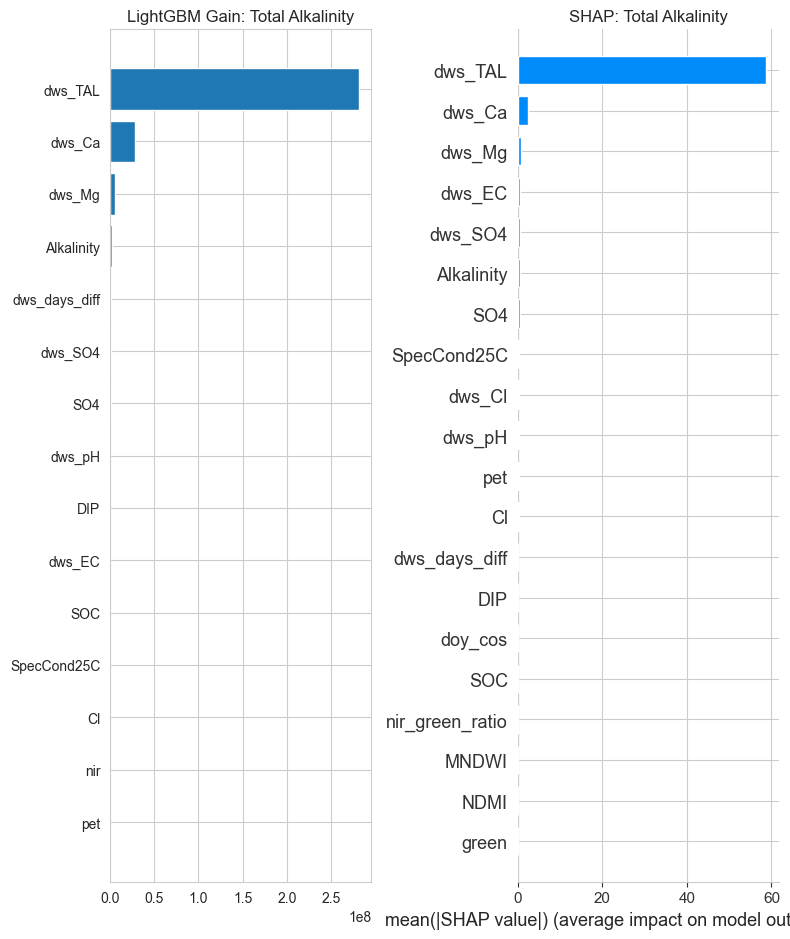


Feature Importance: Electrical Conductance
     Feature         Gain  Split
      dws_EC 2.291695e+10   9261
      dws_Mg 5.618396e+09   4305
      dws_Cl 4.922115e+09   6035
     dws_SO4 4.133231e+09   3091
      dws_Ca 1.324926e+09   4044
     dws_TAL 5.988197e+08   2375
         SOC 4.969882e+08    659
  Alkalinity 4.158836e+08    598
 SpecCond25C 3.379494e+08   1252
          Cl 2.566973e+08   2082
     Soil_pH 2.299059e+08    493
         pet 2.273749e+08   2378
         DIP 1.500942e+08    982
dws_1st_dist 1.417694e+08    288
       green 1.416633e+08   1753


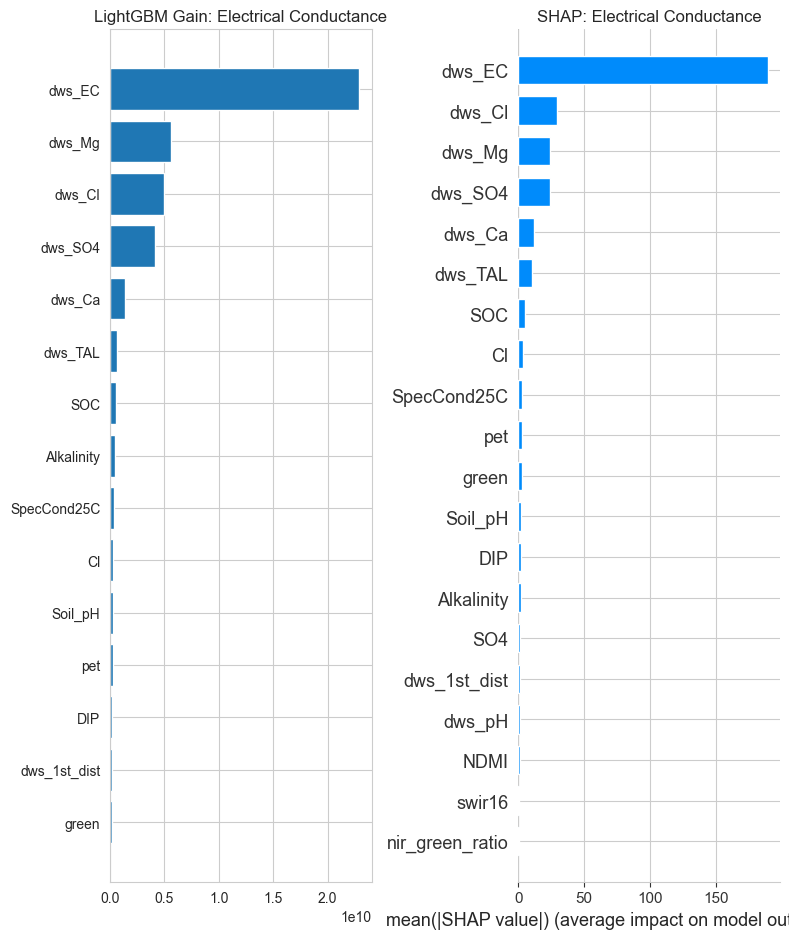


Feature Importance: Dissolved Reactive Phosphorus
       Feature         Gain  Split
dws_P_modified 66559.018387   2441
           pet  2376.325754   1911
           DIP  2306.611363    903
          year  1969.336125    644
            pH  1522.127070    771
  dws_1st_dist  1362.251758    257
           SOC   966.228610    359
       dws_TAL   873.881651   1493
           SO4   755.684529    400
        dws_Ca   726.684061   1380
        dws_pH   669.799844   1438
       dws_SO4   615.128354   1231
        dws_Cl   578.195565   1055
         MNDWI   513.281423   1199
        dist_m   466.325223    345


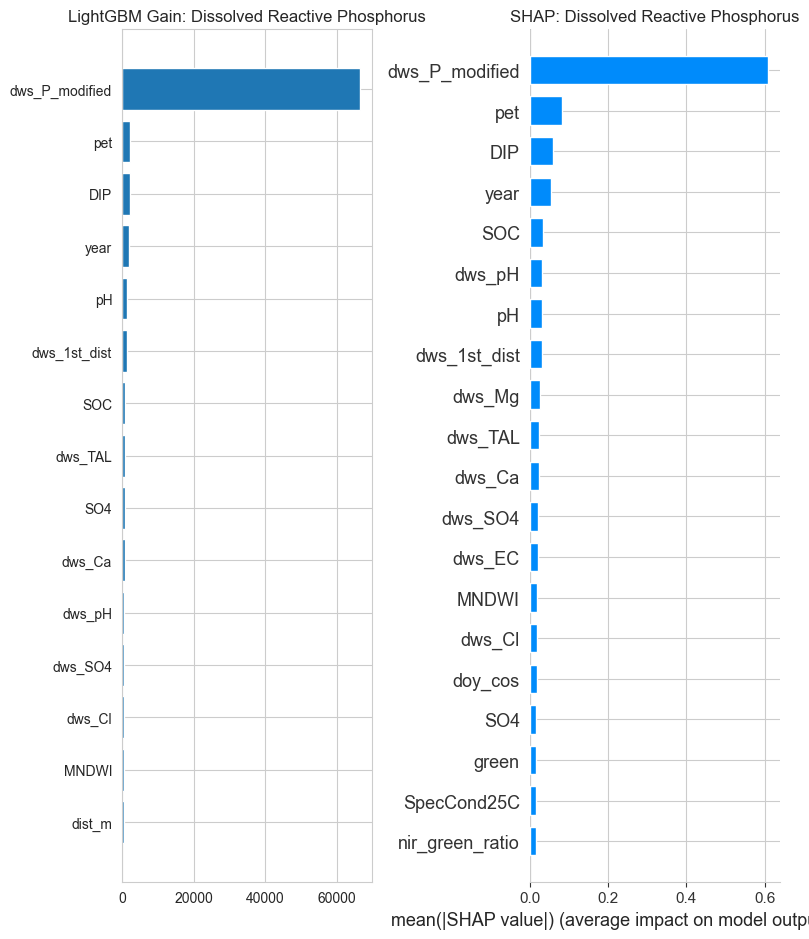

In [12]:
# ==========================================
# 9. FEATURE IMPORTANCE (LightGBM)
# ==========================================
for target in Config.TARGETS:
    model = models[target]
    print(f"\n{'='*40}")
    print(f"Feature Importance: {target}")
    print(f"{'='*40}")
    
    # Built-in importance
    fi = pd.DataFrame({
        'Feature': X_train_clean.columns,
        'Gain': model.booster_.feature_importance(importance_type='gain'),
        'Split': model.booster_.feature_importance(importance_type='split')
    }).sort_values('Gain', ascending=False)
    
    print(fi.head(15).to_string(index=False))
    
    # SHAP (sample for speed)
    X_sample = X_train_clean.sample(min(500, len(X_train_clean)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].barh(fi.head(15)['Feature'][::-1], fi.head(15)['Gain'][::-1])
    axes[0].set_title(f'LightGBM Gain: {target}')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
    axes[1].set_title(f'SHAP: {target}')
    
    plt.tight_layout()
    plt.show()

In [13]:
# ==========================================
# 10. SAVE BEST PARAMS FOR REPRODUCIBILITY
# ==========================================
results_summary = {
    'model': 'LightGBM',
    'cv_scores': cv_scores,
    'mean_r2': float(np.mean(list(cv_scores.values()))),
    'best_params': {k: {kk: (float(vv) if isinstance(vv, (np.floating, float)) else int(vv) if isinstance(vv, (np.integer, int)) else vv) for kk, vv in v.items()} for k, v in best_params_all.items()}
}

with open(f'{Config.BASE_DIR}/lgbm_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Results saved to lgbm_results.json")
print(json.dumps(results_summary, indent=2))

Results saved to lgbm_results.json
{
  "model": "LightGBM",
  "cv_scores": {
    "Total Alkalinity": 0.986488601789396,
    "Electrical Conductance": 0.9155872485620641,
    "Dissolved Reactive Phosphorus": 0.6217145820749028
  },
  "mean_r2": 0.8412634774754544,
  "best_params": {
    "Total Alkalinity": {
      "learning_rate": 0.08476159934364255,
      "num_leaves": 45,
      "max_depth": 4,
      "reg_alpha": 0.04109351278948297,
      "reg_lambda": 0.0795352106619887,
      "min_child_samples": 21,
      "subsample": 0.5095490698133802,
      "colsample_bytree": 0.932322995770476
    },
    "Electrical Conductance": {
      "learning_rate": 0.012647126359447989,
      "num_leaves": 33,
      "max_depth": 8,
      "reg_alpha": 0.004839121578964209,
      "reg_lambda": 0.006056781073200217,
      "min_child_samples": 20,
      "subsample": 0.7457886120046757,
      "colsample_bytree": 0.6311573733608628
    },
    "Dissolved Reactive Phosphorus": {
      "learning_rate": 0.04449547

In [21]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 79 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Latitude                       9319 non-null   float64
 1   Longitude                      9319 non-null   float64
 2   Sample Date                    9319 non-null   object 
 3   Total Alkalinity               9319 non-null   float64
 4   Electrical Conductance         9319 non-null   float64
 5   Dissolved Reactive Phosphorus  9319 non-null   float64
 6   pet                            9319 non-null   float64
 7   _merge_terra                   9319 non-null   object 
 8   nir                            9319 non-null   float64
 9   green                          9319 non-null   float64
 10  swir16                         9319 non-null   float64
 11  swir22                         9319 non-null   float64
 12  NDMI                           9319 non-null   f